In [3]:
 ## This project entails at Predictive Modelling with Python. Forecast future job salaries
## Import libraries onto our environment to work with
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats


In [3]:
## Read our data 
jobs_df = pd.read_csv(r"C:\Users\Gifton\Videos\0.0002 DATA ANALYTICS\2026, APRIL PROJECTS\103 PROJECT\job_salary_prediction_dataset.csv")
jobs_df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [5]:
##Create a copy of Data Frame to work with
jobs_df1 = jobs_df.copy()
jobs_df1

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [8]:
##Check for any missing values and any duplicates in our data
    ## Missing values:
jobs_df1.isna().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [9]:
## Duplicates:
jobs_df1.duplicated().sum()

0

In [10]:
##PART A. LINEAR REGRESSION MODEL BUILDING
    # First explore relationship between Jobs Salary and the number of Years in Experience
    # The Y variable (Salary) and X variable (Experiece_years)
x =jobs_df1[['experience_years']]
y =jobs_df1[['salary']]
ols_data = jobs_df1[['experience_years', 'salary']]
ols_data

,experience_years,salary
0,10,109413
1,5,93764
2,18,148123
3,19,189123
4,15,165069
...,...,...
249995,17,127791
249996,20,154593
249997,1,75988
249998,0,90467


In [11]:
## Having defined X and Y variable, we then formulate a Linear Regression Model
ols_formula = 'salary ~ experience_years'

In [12]:
## Import the OLS module from STATS.MODELS
from statsmodels.formula.api import ols

In [13]:
## Then fit the Linear Regression Model using data defined by X and Y variables
ols_model = ols(formula=ols_formula, data=ols_data)
model = ols_model.fit()

In [15]:
## Obtain Summary statistics having fitted our Model
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 salary   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                 5.922e+04
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:58:41   Log-Likelihood:            -2.9606e+06
No. Observations:              250000   AIC:                         5.921e+06
Df Residuals:                  249998   BIC:                         5.921e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1.187e+05    129.843    914.114      0.000    1.18e+05    1.19e+05
experience_years  2701.1730     11.100    243.353      0.000    2679.418    2722.928
==============================================================================
Omnibus:                     4298.287   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4565.909
Skew:                           0.314   Prob(JB):                         0.00
Kurtosis:                       3.208   Cond. No.                         22.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
## RESULT SUMMARY INTERPRETATIONS
    # For the experience_years variable the coefficient is 2,701. Implies that for every one experience_years, the Salary increases by a value of 2,701

In [ ]:
## THE P-VALUE
    #P-Value is 0.000 which is a value less than 0.05. Implies that the result is Statistically  Significant.

<Axes: xlabel='experience_years', ylabel='salary'>

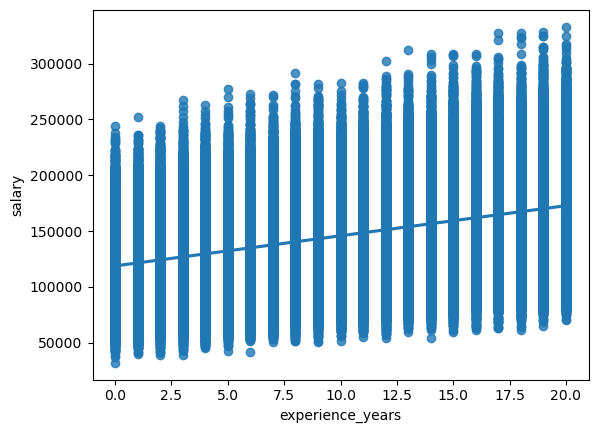

In [16]:
## Obtain a Visual Plot using the regplot() from seaborn
sns.regplot(x='experience_years', y='salary', data=ols_data)


In [18]:
## Check for Assumption to Justify if the Model is Best for modelling this data.
# We shall check for[Normality and Homoscedcity] Assumptions.
    #1.Subset the X variable from the data
x = ols_data['experience_years']


In [19]:
    #2. Obtain the predictions from the model
fitted_values = model.predict(x)

In [20]:
    #3. Obtain the residuals
residuals = model.resid

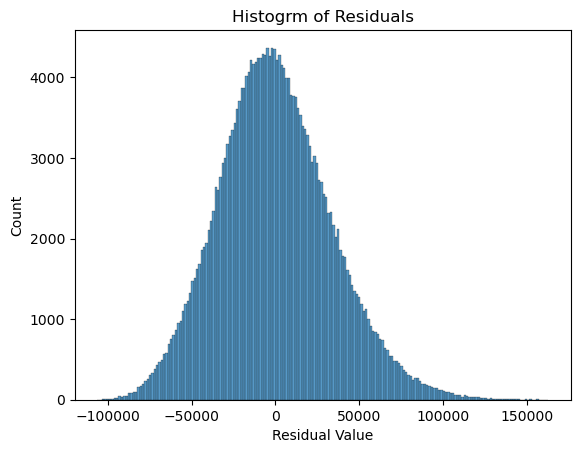

In [21]:
    #4. We create a histogram to check for the Normality assumption
fig = sns.histplot(residuals)
fig.set_xlabel('Residual Value')
fig.set_title('Histogrm of Residuals')
plt.show()

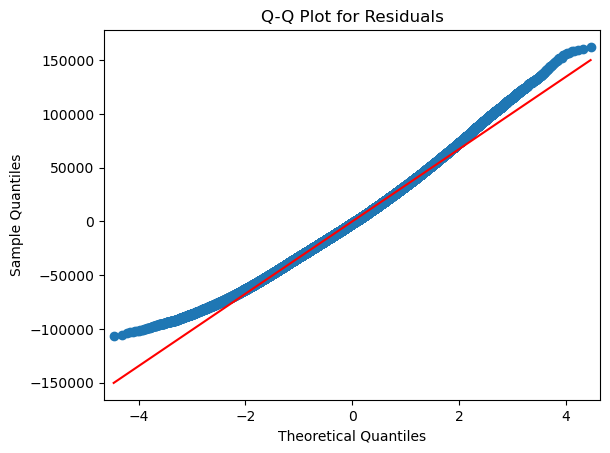

In [22]:
    #5. Use the Quantiles-Quantiles (Q-Qplot) to check for the Normality assumptions
fig = sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot for Residuals')
plt.show()



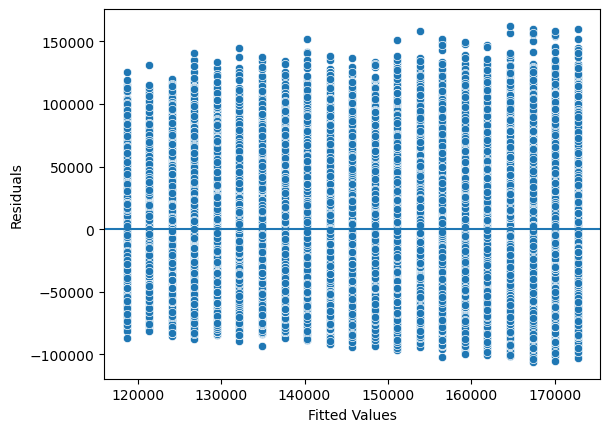

In [23]:
    #6. Check for the Homoscedacity Assumption
fig = sns.scatterplot(x=fitted_values, y=residuals)
fig.axhline(0)
fig.set_xlabel("Fitted Values")
fig.set_ylabel("Residuals")
plt.show()


In [24]:
jobs_df1.head(2)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764


In [25]:
## PARTB. MULTIPLE LINEAR REGRESSION MODEL
    #Assume we would like to predict the Jobs Salary based on More than one Continous variable(experience_years, skills and certications)
    # For such case we build a Multiple Linear Regression

## STEP 1. Create a Subset for the X and Y variables
jobs_x = jobs_df1[['experience_years', 'skills_count', 'certifications']]
jobs_y = jobs_df1[['salary']]

In [26]:
## STEP 2. IMPORT The train_split function from SCI-KIT LEARN
from sklearn.model_selection import train_test_split

In [27]:
## STEP 3. Create training dataset nd a Holdout sample datasets
x_train, x_test, y_train, y_test = train_test_split(jobs_x, jobs_y, test_size=0.3, random_state=42)
    #The test size=0.3 (30%) tells the function the PROPORTION of data to be in the Hold Out Sample. We hold 30% of the data to test the model
    #The random_state=42 is for reproducibility purposes

In [28]:
## STEP 4. MODEL CONSTRUCTION
ols_formula = 'salary ~ experience_years + skills_count + certifications'
    #We define the OLS formula for the Single Y variable and the X Variables

In [29]:
# We import the ols() function
from statsmodels.formula.api import ols

In [30]:
# We create the OLS Data Frame
ols_data = pd.concat([x_train, y_train], axis=1)

In [31]:
# We then create an OLS Obect and fit the MODEL
OLS = ols(formula=ols_formula, data=ols_data)
model = OLS.fit()

In [32]:
## Obtain the Summary result of the Model AS:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 salary   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                 1.585e+04
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:02:47   Log-Likelihood:            -2.0701e+06
No. Observations:              175000   AIC:                         4.140e+06
Df Residuals:                  174996   BIC:                         4.140e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1.058e+05    240.950    439.162      0.000    1.05e+05    1.06e+05
experience_years  2708.9348     13.102    206.763      0.000    2683.256    2734.614
skills_count       869.0378     14.493     59.964      0.000     840.632     897.443
certifications    1636.2211     46.453     35.223      0.000    1545.175    1727.267
==============================================================================
Omnibus:                     2889.449   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3069.703
Skew:                           0.306   Prob(JB):                         0.00
Kurtosis:                       3.215   Cond. No.                         47.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
# RESULTS INTERPRETATIONS
#USING THE COEFFICIENTS (experience_years: 2708.9348, Skills_count:869.0378 AND certifications:1636.2211)
    #For EXPERIENCE_YEARS; Holding skills and certification variables constant, we expect sALARY to increase by 2,708
    #For Skills; Holding experience years and certifications variables constant, we expect SALARY to increase by 869
    #For Certifications: Holding the experience and skills variables constant, we expect SALARY to increaswe by 1,636

In [34]:
## PVALUES INTERPRETATIONS
    # Each of the P value obtain is 0.000 which is less than 0.05 IMPLYIG that the 3 Coefficients (experience, skills and certifications) are Statistically Significant.
